### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('grades_crpt.csv')

### Part 1: Data Exploration ###

1. Look at basic stats, column names, and what the data looks like

2. Identify anything that stands out right away

In [36]:
# 1. Look at basic stats, column names, and what the data looks like
print("Shape:", df.shape)
print("Columns:", df.columns)

df.info()
display(df.describe())
display(df)

Shape: (86, 9)
Columns: Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam', 'user_id'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


# Observations
1) Several NaN numbers
2) there are 0's and NaN numbers
3) several numbers over 100%
4) A1 has the most count of uncompleted 

### Part 2: Correlations ###

1. Use a correlation matrix to find relationships between assignments and the final exam

2. Do any assignments seem strongly related to final exam performance?

In [37]:
# 1. Correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                  A1        A2        A3        A4        A5        A6  \
A1          1.000000 -0.141322  0.363341  0.299973  0.242348  0.233172   
A2         -0.141322  1.000000  0.209836 -0.027420  0.011602  0.356759   
A3          0.363341  0.209836  1.000000  0.189807  0.191534 -0.032497   
A4          0.299973 -0.027420  0.189807  1.000000  0.039064  0.146504   
A5          0.242348  0.011602  0.191534  0.039064  1.000000  0.241590   
A6          0.233172  0.356759 -0.032497  0.146504  0.241590  1.000000   
A7         -0.020569  0.031056  0.145332  0.223921  0.031902  0.147876   
Final_Exam  0.212839  0.284525  0.277859  0.403466  0.018271  0.246127   

                  A7  Final_Exam  
A1         -0.020569    0.212839  
A2          0.031056    0.284525  
A3          0.145332    0.277859  
A4          0.223921    0.403466  
A5          0.031902    0.018271  
A6          0.147876    0.246127  
A7          1.000000    0.380756  
Final_Exam  0.380756    1.000000  


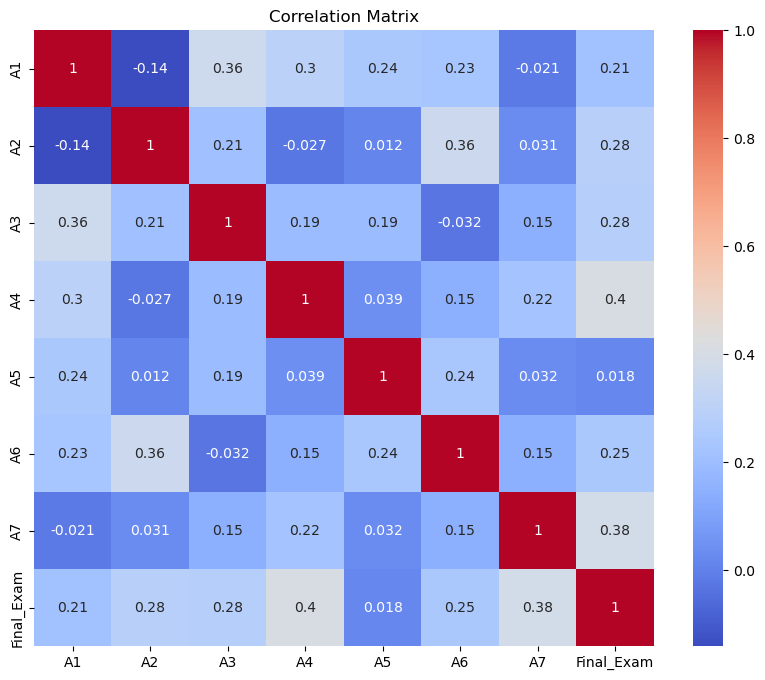

In [38]:
# 2. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Strongest correlation with Final Exam: A4 (0.403)
Weakest correlation with Final Exam:   A5 (0.018)

All assignments ranked by correlation with Final Exam:
A4    0.403466
A7    0.380756
A2    0.284525
A3    0.277859
A6    0.246127
A1    0.212839
A5    0.018271
Name: Final_Exam, dtype: float64


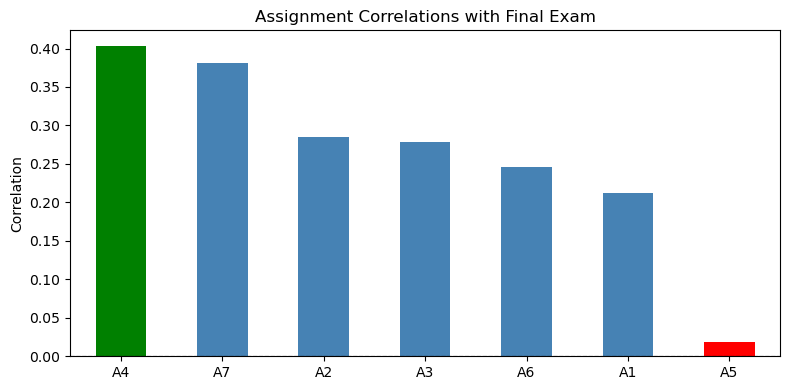

In [39]:
# 3. Strongest and weakest correlations with the final exam
final_corr = corr_matrix['Final_Exam'].drop('Final_Exam').sort_values(ascending=False)

strongest = final_corr.idxmax()
weakest = final_corr.idxmin()

print(f"Strongest correlation with Final Exam: {strongest} ({final_corr[strongest]:.3f})")
print(f"Weakest correlation with Final Exam:   {weakest} ({final_corr[weakest]:.3f})")
print()
print("All assignments ranked by correlation with Final Exam:")
print(final_corr)

# Bar chart for a clearer visual comparison
plt.figure(figsize=(8, 4))
colors = ['green' if v == final_corr.max() else 'red' if v == final_corr.min() else 'steelblue' for v in final_corr]
final_corr.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Assignment Correlations with Final Exam')
plt.ylabel('Correlation')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Observations
- A4 has the highest correlation with the final exam
- A5 has basically no correlation with the final exam
- Ranking of correlation is A4, A7, A2, A3, A6, A1, and A5
- There are no blatantly obvious correlation between the assignments and final exam
- The values are not trust worthy either when factoring in NaN values

### Part 3: Assignment Selection ###

1. If you could only use two assignment grades to predict the final exam, which ones would you choose — and why?

In [40]:
assignments = ['A4', 'A7']
print(corr_matrix['Final_Exam'][assignments])

A4    0.403466
A7    0.380756
Name: Final_Exam, dtype: float64


## Observations
- I chose A4 and A7 because they have the highest correlation with the final exam
- A4 has the highest correlation of 0.403 meaning students who did well on the assignment also had a higher chance of doing well in the final exam
- A7 is the second strongest correlation of 0.381
- the other assignments are all significantly lower correlation so A4 and A7 were the best picks.

### Part 4: Missing Values ###

1. Which columns have them?

2. How many are missing?

A1            29
A2            25
A3            24
A4             9
A5            25
A6            19
A7            10
Final_Exam     0
user_id        0
dtype: int64


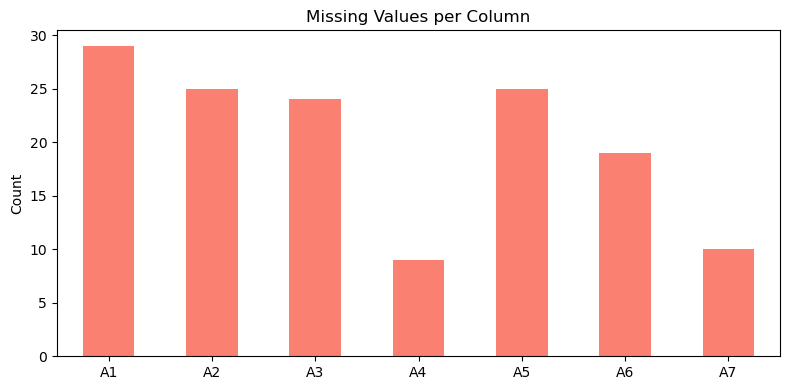

In [41]:
# Count missing values per column
print(df.isnull().sum())

# Bar Chart
missing = df.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='salmon')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Observations
- Every assignment has a missing value except final exams and user id.
- A1 has the most amount of missing values with a count of 29
- A4 has the least amount of missing values with a count of 9
- Coincidentally A4 and A7 both have highest correlation to the final exam as well being the lowest missing value assignments

### Part 5: Handling Missing Values ###

1. Try out different imputation strategies (mean, median, remove, etc.)

2. Which one gives you the best results? Why do you think that is?

3. Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

Original shape: (86, 9)
After drop:  (13, 9)

Std comparison (closer to Original = better):


,Original std,Mean std,Median std
A1,34.286481,27.829632,27.889104
A2,28.556721,23.992445,24.423614
A3,42.343621,35.870997,36.265628
A4,39.101984,36.973973,37.008191
A5,25.510505,21.433111,21.572171
A6,31.176535,27.472004,27.569905
A7,26.412058,24.809808,24.817132


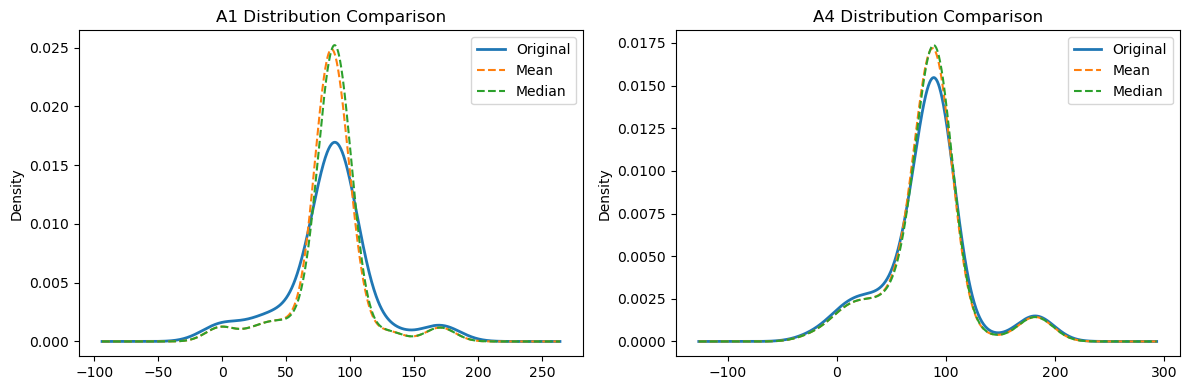

In [42]:
assignment_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']

# Mean
df_mean = df.fillna(df.mean(numeric_only=True))

# Median
df_median = df.fillna(df.median(numeric_only=True))

# Drop
df_drop = df.dropna()

print("Original shape:", df.shape)
print("After drop: ", df_drop.shape)

comparison = pd.DataFrame({
    'Original std': df[assignment_cols].std(),
    'Mean std': df_mean[assignment_cols].std(),
    'Median std': df_median[assignment_cols].std()
})
print("\nStd comparison (closer to Original = better):")
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['A1'].plot(kind='kde', ax=axes[0], label='Original', linewidth=2)
df_mean['A1'].plot(kind='kde', ax=axes[0], label='Mean', linestyle='--')
df_median['A1'].plot(kind='kde', ax=axes[0], label='Median', linestyle='--')
axes[0].set_title('A1 Distribution Comparison')
axes[0].legend()

df['A4'].plot(kind='kde', ax=axes[1], label='Original', linewidth=2)
df_mean['A4'].plot(kind='kde', ax=axes[1], label='Mean', linestyle='--')
df_median['A4'].plot(kind='kde', ax=axes[1], label='Median', linestyle='--')
axes[1].set_title('A4 Distribution Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

## Observations

- Remove strategy resulted in only 13 rows out of 86 which is bad since that means majoirty of the data is gone so its not reliable
- When comparing the mean and the median strategy, you realize that median is alot better because median is unaffected by outliers versus mean, it is affected by outliers skewing the mean higher or lower.
- Therefore median is best
- As you can see from the plot above using the least correlated assignment and the most correlated assignment you can see that the one closest to the actual original line is better and in the first case you can see mean is skewed a little to the left while for A4 both mean and median are relatively in the middle same as the original distribution.

### Part 6: Outliers ###

1. Identify values that seem unrealistic or suspicious

2. Decide whether to keep, modify, or remove them — and explain your reasoning

3. Compare the results

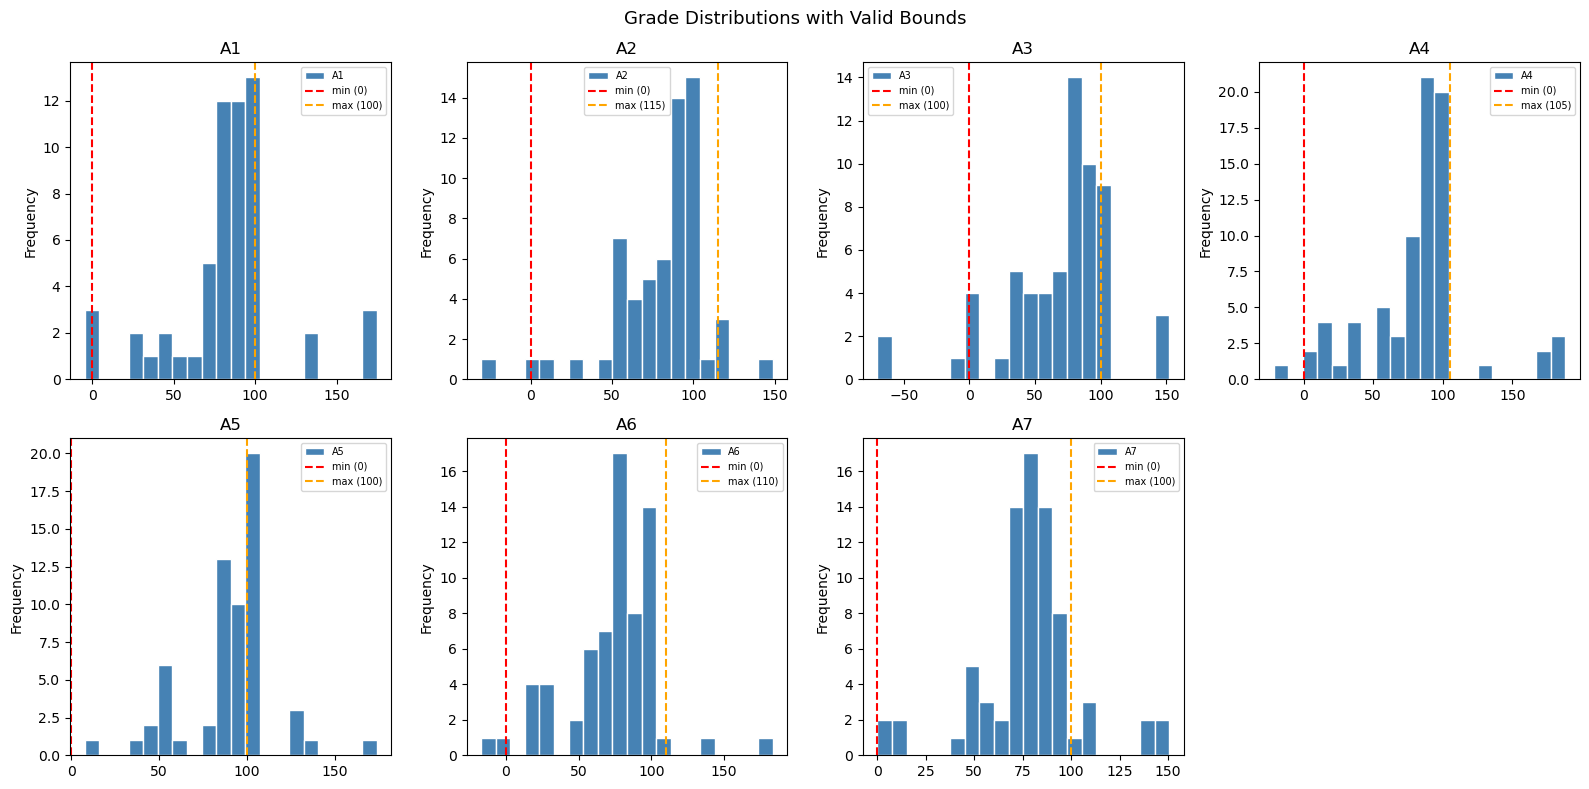

Before:


,A1,A2,A3,A4,A5,A6,A7
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000


After:


,A1,A2,A3,A4,A5,A6,A7
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000
mean,78.975439,81.042623,68.080645,77.251948,86.326230,73.198507,75.378947
std,26.092379,25.684518,31.944777,28.330714,20.241681,26.968357,21.411388
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000
max,100.000000,115.000000,100.000000,105.000000,100.000000,110.000000,100.000000


In [43]:
assignment_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']

# 1. Histogram per assignment with valid bounds marked
bounds = {'A1': 100, 'A2': 115, 'A3': 100, 'A4': 105, 'A5': 100, 'A6': 110, 'A7': 100}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# https://docs.python.org/3/library/functions.html#enumerate
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html
# https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
for i, col in enumerate(assignment_cols):
    df[col].plot(kind='hist', ax=axes[i], bins=20, color='steelblue', edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', label='min (0)')
    axes[i].axvline(bounds[col], color='orange', linestyle='--', label=f'max ({bounds[col]})')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Grade Distributions with Valid Bounds', fontsize=13)
plt.tight_layout()
plt.show()

# 2. Clip bad values to their valid grade range (0 to max)
df_clean = df.copy()
df_clean[['A1', 'A3', 'A5', 'A7']] = df_clean[['A1', 'A3', 'A5', 'A7']].clip(0, 100)
# A2 has up to 15 bonus points
df_clean['A2'] = df_clean['A2'].clip(0, 115)
# A4 has up to 5 bonus points
df_clean['A4'] = df_clean['A4'].clip(0, 105)
# A6 has up to 10 bonus points
df_clean['A6'] = df_clean['A6'].clip(0, 110)

# 3. Compare before and after
print("Before:"); display(df[assignment_cols].describe())
print("After:");  display(df_clean[assignment_cols].describe())

## Observations

Suspicious values identified:
- There are negative scores in A1, A2, A3, A4, A6
- There are numbers way above 100 which is way over the point percentage?

Modify the data:
- Clipping would preserve most of the proper values and since not every assignment is graded the same then other assignemnts may get removed if we remove it

Comparison:
- There are no longer negative values
- Max value adjusted according to max bonus marks per assignment
- The mean dropped slightly across since outlierswere skewing it
- Less spread on data and more representative of performance
